# ЛР: Прямое и обратное преобразование Радона

---

## Теория

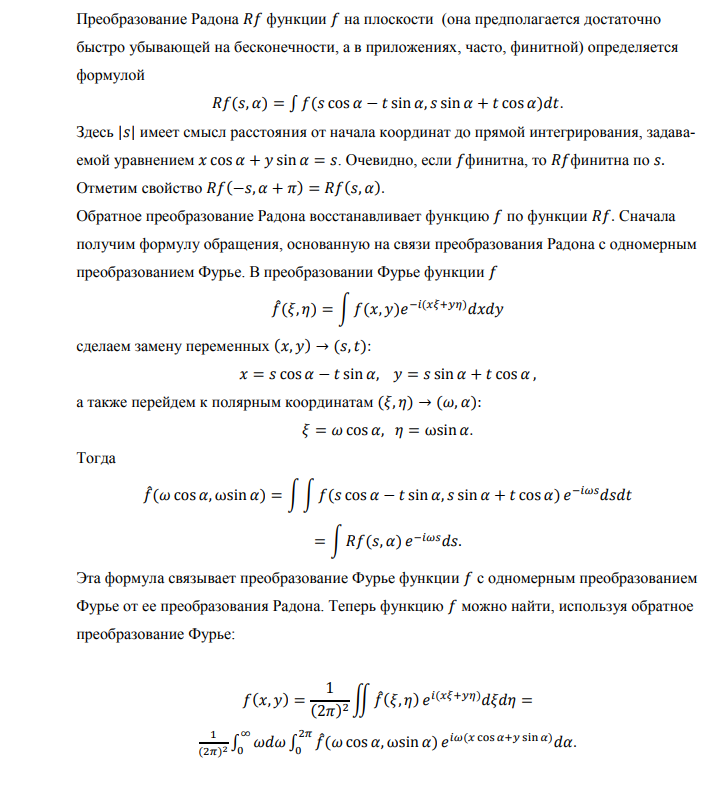



In [17]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color, util
from skimage.transform import radon, iradon, resize
from skimage.metrics import mean_squared_error

img_path = 'source.png'
img = io.imread(img_path)

In [18]:
# Если RGBA — отбросить alpha-канал
if img.ndim == 3 and img.shape[2] == 4:
    img = img[:, :, :3]

# Перевод в grayscale Y = 0.2125 R + 0.7154 G + 0.0721 B
if img.ndim == 3:
    img = color.rgb2gray(img)
img = util.img_as_float(img)

# Приведение к квадрату 256x256
N = 256
img = resize(img, (N, N), anti_aliasing=True) # anti_aliasing = Gaussian filter
img = np.clip(img, 0.0, 1.0)


In [ ]:
import numpy as np

def radon_explicit(img, theta):
    """
    Radon transform через явные полярные координаты (rho, theta).
    img : 2D numpy array
        Исходное изображение.
    theta : array_like
        Массив углов в градусах, под которыми строим проекции.

    """
    # размеры изображения
    n_y, n_x = img.shape

    # координаты пикселей относительно центра изображения
    x = np.arange(n_x) - n_x // 2
    y = np.arange(n_y) - n_y // 2
    X, Y = np.meshgrid(x, y)  # создаём сетку координат (x, y) для каждого пикселя

    # количество точек вдоль детектора (ρ)
    n_s = max(n_x, n_y)
    sinogram = []  # сюда будем складывать проекции

    # перебираем каждый угол θ
    for angle in theta:
        theta_rad = np.deg2rad(angle)  # переводим угол в радианы

        # для каждого пикселя вычисляем координату ρ вдоль линии под углом θ
        rho = X * np.cos(theta_rad) + Y * np.sin(theta_rad)

        # создаём дискретные “контейнеры” для ρ (аналог детектора)
        rho_bins = np.linspace(rho.min(), rho.max(), n_s)

        # создаём массив для проекции под этим углом
        proj = np.zeros(n_s)

        # суммируем пиксели, которые попадают в каждый ρ-bin
        for i in range(n_s-1):
            mask = (rho >= rho_bins[i]) & (rho < rho_bins[i+1])  # маска пикселей для текущего ρ
            proj[i] = img[mask].sum()  # суммируем интенсивности пикселей

        sinogram.append(proj)  # добавляем проекцию к синограмме

    return np.array(sinogram).T  # транспонируем: строки = s, столбцы = углы

# ------------------------------------------------------------------------------

def iradon_explicit(sinogram, theta):
    """
    Обратное проецирование (Filtered Back Projection без фильтра)
    через явные координаты ρ.

    Parameters
    ----------
    sinogram : 2D numpy array
        Синограмма: строки — координаты детектора, столбцы — углы.
    theta : array_like
        Массив углов в градусах.

    Returns
    -------
    recon : 2D numpy array
        Восстановленное изображение.
    """
    n_s, n_theta = sinogram.shape  # размеры синограммы
    recon = np.zeros((n_s, n_s))  # сюда складываем восстановленное изображение

    # координаты пикселей изображения относительно центра
    x = np.arange(n_s) - n_s // 2
    y = np.arange(n_s) - n_s // 2
    X, Y = np.meshgrid(x, y)

    # дискретные координаты ρ (как в Radon transform)
    rho_bins = np.linspace(-(n_s//2), n_s//2, n_s)

    # перебираем каждый угол θ
    for i, angle in enumerate(theta):
        theta_rad = np.deg2rad(angle)  # угол в радианах

        # координата ρ для каждого пикселя под текущим углом
        rho = X * np.cos(theta_rad) + Y * np.sin(theta_rad)

        proj = sinogram[:, i]  # текущая проекция для θ[i]

        # интерполяция значений проекции на каждый пиксель
        # np.interp возвращает значение проекции для каждого rho
        recon += np.interp(rho.flatten(), rho_bins, proj).reshape(n_s, n_s)

    # нормализация по количеству углов
    recon /= len(theta)

    return recon

In [ ]:

steps = [1, 5, 10]
results = {}

for step in steps:
    theta = np.arange(0, 180, step)
    sinogram = radon(img, theta=theta, circle=False)
    recon = iradon(sinogram, theta=theta, circle=False, filter_name='ramp')

    mse = mean_squared_error(img, recon)

    results[step] = dict(
        theta=theta,
        sinogram=sinogram,
        recon=recon,

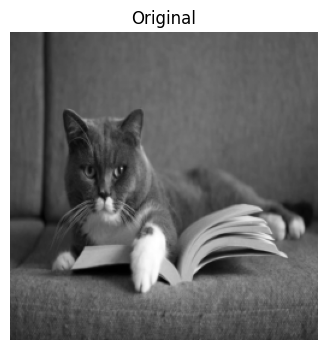

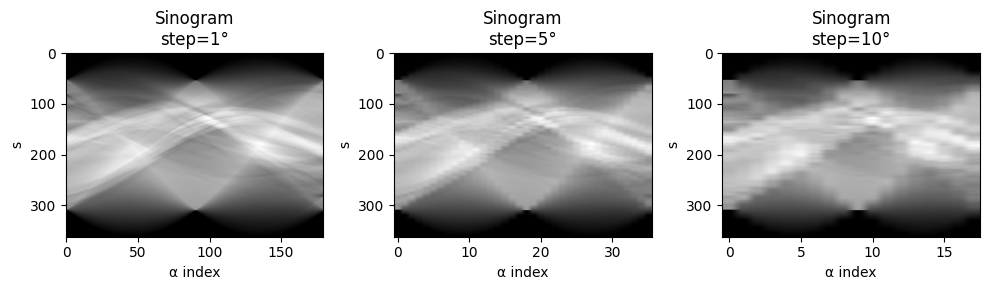

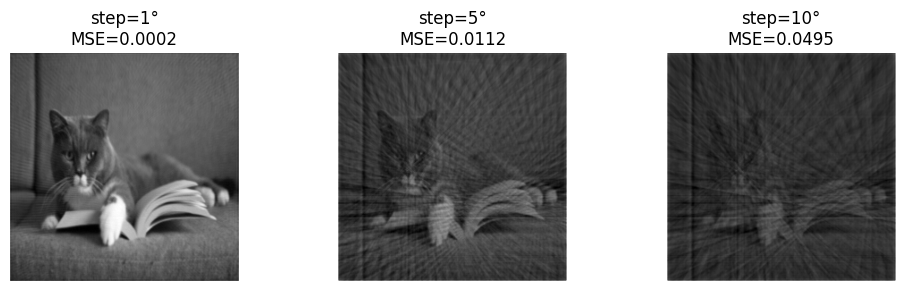

Шаг (°)	Число проекций	Среднеквадратичная ошибка (MSE)
1			180		0.000207
5			36		0.011217
10			18		0.049540


In [19]:
        mse=mse
    )

# --- Визуализация ---
plt.figure(figsize=(4, 4))
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 3))
for i, step in enumerate(steps, 1):
    plt.subplot(1, 3, i)
    plt.imshow(results[step]['sinogram'], cmap='gray', aspect='auto')
    plt.title(f'Sinogram\nstep={step}°')
    plt.xlabel('α index')
    plt.ylabel('s')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3))
for i, step in enumerate(steps, 1):
    plt.subplot(1, 3, i)
    r = results[step]
    plt.imshow(r["recon"], cmap='gray')
    plt.title(f'step={step}°\nMSE={r["mse"]:.4f}')
    plt.axis('off')
plt.tight_layout()
plt.show()

print('Шаг (°)\tЧисло проекций\tСреднеквадратичная ошибка (MSE)')
for step in steps:
    r = results[step]
    print(f"{step}\t\t\t{len(r['theta'])}\t\t{r['mse']:.6f}")
